In [40]:
%matplotlib inline

In [2]:
import os
import sys
from pathlib import Path

!pip install opencv-python matplotlib numpy pandas seaborn scikit-learn

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `pip install -r {Path(os.getcwd()).parent / "requirements.txt"}'


In [10]:
import os
import sys
import json
import yaml
import time
import warnings
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import torch
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import cv2
from ultralytics import YOLO, RTDETR

PROJECT_ROOT = Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import importlib.util
spec = importlib.util.spec_from_file_location("database", PROJECT_ROOT / "src" / "database" / "database.py")
database = importlib.util.module_from_spec(spec)
spec.loader.exec_module(database)
get_db = database.get_db

from utils.logger import ModelLogger, save_results

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

db = get_db()
print("База данных подключена")

База данных подключена


In [11]:
PROJECT_ROOT = Path("../").resolve()

DATA_ROOT = PROJECT_ROOT / "data" / "data"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

YAML_PATH = PROJECT_ROOT / "configs" / "dataset_config.yaml"

MODELS = {
    "YOLOv8n": PROJECT_ROOT / "models/weights/trained/yolo_n/best.pt",
    "YOLOv8s": PROJECT_ROOT / "models/weights/trained/yolo_s/best.pt",
    "YOLOv8m": PROJECT_ROOT / "models/weights/trained/yolo_m/best.pt",
    "RT-DETR": PROJECT_ROOT / "models/weights/trained/rtdetr/best.pt",
    "Faster R-CNN": PROJECT_ROOT / "models/weights/trained/faster_rcnn/faster_rcnn/best.pth"
}

In [12]:
dataset_yaml = {
    "path": str(DATA_ROOT),
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "nc": 1,
    "names": ["license_plate"]
}

with open(YAML_PATH, "w", encoding="utf-8") as f:
    yaml.safe_dump(dataset_yaml, f, sort_keys=False, allow_unicode=True)

assert (DATA_ROOT / "train/images").exists(), "train/images не найден"
assert (DATA_ROOT / "val/images").exists(), "val/images не найден"
assert (DATA_ROOT / "test/images").exists(), "test/images не найден"

In [13]:
def log_evaluation_to_db(model_name, metrics):
    try:
        experiment_name = f"{model_name}_evaluation_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
        
        model_type = 'yolo'
        if 'RT-DETR' in model_name:
            model_type = 'rtdetr'
        elif 'Faster' in model_name:
            model_type = 'faster_rcnn'
        
        db.log_experiment({
            'experiment_name': experiment_name,
            'model_name': model_name,
            'model_type': model_type,
            'dataset_path': str(DATA_ROOT),
            'training_params': json.dumps({
                'action': 'evaluation',
                'split': 'test',
                'timestamp': datetime.now().isoformat()
            }),
            'start_time': datetime.now().isoformat(),
            'end_time': datetime.now().isoformat(),
            'total_epochs': 0,
            'best_epoch': 0,
            'best_val_loss': 0,
            'final_train_loss': 0,
            'final_val_loss': 0,
            'mAP50': metrics.get('mAP50', 0),
            'mAP50_95': metrics.get('mAP50_95', 0),
            'precision': metrics.get('Precision', 0),
            'recall': metrics.get('Recall', 0),
            'f1_score': metrics.get('F1', 0),
            'model_size_mb': metrics.get('Model_size_MB', 0),
            'inference_time_ms': metrics.get('Inference_ms', 0),
            'status': 'evaluated',
            'error_message': None
        })
        print(f"  Логирование в БД: успешно")
    except Exception as e:
        print(f"  Ошибка логирования в БД: {e}")

In [14]:
def evaluate_yolo_model(model_name, model_path):
    print(f"\nОценка {model_name}")

    if "RT-DETR" in model_name:
        model = RTDETR(str(model_path))
    else:
        model = YOLO(str(model_path))

    start = time.time()

    results = model.val(
        data=str(YAML_PATH),
        split="test",
        plots=True,
        save_json=True,
        verbose=False
    )

    total_time = time.time() - start

    precision = float(results.box.mp)
    recall = float(results.box.mr)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)

    metrics = {
        "Model": model_name,
        "mAP50": float(results.box.map50),
        "mAP50_95": float(results.box.map),
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Inference_ms": float(results.speed["inference"]),
        "Preprocess_ms": float(results.speed["preprocess"]),
        "Postprocess_ms": float(results.speed["postprocess"]),
        "Validation_time_sec": total_time,
        "Model_size_MB": round(Path(model_path).stat().st_size / 1024 / 1024, 2)
    }

    print(f"mAP50: {metrics['mAP50']:.4f}, mAP50-95: {metrics['mAP50_95']:.4f}, "
          f"Inference: {metrics['Inference_ms']:.1f}ms, Size: {metrics['Model_size_MB']:.1f}MB")
    
    log_evaluation_to_db(model_name, metrics)

    return metrics

In [15]:
def compute_iou(box1, box2):
    x1, y1, x2, y2 = box1[0] - box1[2]/2, box1[1] - box1[3]/2, box1[0] + box1[2]/2, box1[1] + box1[3]/2
    x3, y3, x4, y4 = box2[0] - box2[2]/2, box2[1] - box2[3]/2, box2[0] + box2[2]/2, box2[1] + box2[3]/2
    
    x_left = max(x1, x3)
    y_top = max(y1, y3)
    x_right = min(x2, x4)
    y_bottom = min(y2, y4)
    
    if x_right < x_left or y_bottom < y_top:
        return 0.0
    
    intersection = (x_right - x_left) * (y_bottom - y_top)
    area1 = (x2 - x1) * (y2 - y1)
    area2 = (x4 - x3) * (y4 - y3)
    union = area1 + area2 - intersection
    
    return intersection / union

In [16]:
def evaluate_faster_rcnn(model_name, model_path):
    print(f"\nОценка {model_name}")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    checkpoint = torch.load(model_path, map_location=device)
    
    num_classes = 2
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=False)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    
    model.to(device)
    model.eval()

    test_images_dir = DATA_ROOT / "test" / "images"
    test_labels_dir = DATA_ROOT / "test" / "labels"
    
    image_paths = sorted(test_images_dir.glob("*.jpg")) + sorted(test_images_dir.glob("*.bmp"))
    
    all_preds = []
    all_targets = []
    
    start = time.time()
    inference_times = []
    
    with torch.no_grad():
        for img_path in tqdm(image_paths, desc="Оценка Faster R-CNN"):
            img = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            img_tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0
            img_tensor = img_tensor.unsqueeze(0).to(device)
            
            t_start = time.time()
            outputs = model(img_tensor)
            inference_times.append((time.time() - t_start) * 1000)
            
            label_path = test_labels_dir / img_path.with_suffix('.txt').name
            targets = []
            if label_path.exists():
                with open(label_path, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            cls_id = int(parts[0])
                            x, y, w, h = map(float, parts[1:5])
                            targets.append([cls_id, x, y, w, h])
            all_targets.append(targets)
            
            preds = []
            for output in outputs:
                boxes = output['boxes'].cpu().numpy()
                scores = output['scores'].cpu().numpy()
                labels = output['labels'].cpu().numpy()
                
                for box, score, label in zip(boxes, scores, labels):
                    if score > 0.5 and label == 1:
                        x1, y1, x2, y2 = box
                        img_h, img_w = img.shape[:2]
                        cx = (x1 + x2) / 2 / img_w
                        cy = (y1 + y2) / 2 / img_h
                        w = (x2 - x1) / img_w
                        h = (y2 - y1) / img_h
                        preds.append([0, cx, cy, w, h, float(score)])
            all_preds.append(preds)
    
    total_time = time.time() - start
    
    tp, fp, total_gt = 0, 0, 0
    for targets, preds in zip(all_targets, all_preds):
        total_gt += len(targets)
        matched = [False] * len(targets)
        for pred in preds:
            best_iou = 0.5
            best_idx = -1
            for i, target in enumerate(targets):
                if matched[i]:
                    continue
                iou = compute_iou(pred[1:5], target[1:5])
                if iou > best_iou:
                    best_iou = iou
                    best_idx = i
            if best_idx >= 0:
                matched[best_idx] = True
                tp += 1
            else:
                fp += 1
    
    all_ious = []
    for img_targets, img_preds in zip(all_targets, all_preds):
        for pred in img_preds:
            best_iou = 0
            for target in img_targets:
                iou = compute_iou(pred[1:5], target[1:5])
                best_iou = max(best_iou, iou)
            all_ious.append(best_iou)
    
    if len(all_ious) > 0:
        map50 = sum(1 for iou in all_ious if iou >= 0.5) / len(all_ious)
        map50_95 = np.mean([sum(1 for iou in all_ious if iou >= t) / len(all_ious) 
                            for t in np.arange(0.5, 0.95, 0.05)])
    else:
        map50, map50_95 = 0.0, 0.0
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / total_gt if total_gt > 0 else 0
    f1 = 2 * precision * recall / (precision + recall + 1e-9)

    metrics = {
        "Model": model_name,
        "mAP50": map50,
        "mAP50_95": map50_95,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Inference_ms": np.mean(inference_times) if inference_times else 0,
        "Preprocess_ms": 0.0,
        "Postprocess_ms": 0.0,
        "Validation_time_sec": total_time,
        "Model_size_MB": round(Path(model_path).stat().st_size / 1024 / 1024, 2)
    }

    print(f"mAP50: {metrics['mAP50']:.4f}, mAP50-95: {metrics['mAP50_95']:.4f}, "
          f"Inference: {metrics['Inference_ms']:.1f}ms, Size: {metrics['Model_size_MB']:.1f}MB")
    
    log_evaluation_to_db(model_name, metrics)

    return metrics

In [17]:
all_results = []

for name, path in MODELS.items():
    if not path.exists():
        print(f"Файл не найден: {path}")
        continue

    if "Faster" in name:
        metrics = evaluate_faster_rcnn(name, path)
    else:
        metrics = evaluate_yolo_model(name, path)

    all_results.append(metrics)

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(by="mAP50", ascending=False)
results_df


Оценка YOLOv8n
Ultralytics 8.4.70 🚀 Python-3.12.11 torch-2.12.1+cu130 CPU (Intel Core i7-7700K 4.20GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 2.1±0.3 ms, read: 10.0±5.3 MB/s, size: 268.3 KB)
val: Scanning /home/jovyan/work/data/data/test/labels.cache... 769 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 769/769 124.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 5.3s/it 4:216.8ss
                   all        769        809      0.983      0.974      0.992      0.818
Speed: 4.2ms preprocess, 299.2ms inference, 0.0ms loss, 2.1ms postprocess per image
Saving /home/jovyan/work/notebooks/runs/detect/val/predictions.json...
Results saved to /home/jovyan/work/notebooks/runs/detect/val
mAP50: 0.9919, mAP50-95: 0.8177, Inference: 299.2ms, Size: 6.0MB
  Логирование в БД: успешно

Оценка YOLOv8s
Ultralytics 8.4.70 🚀 Python-3.12.11 torch-2.1

100%|██████████| 97.8M/97.8M [00:11<00:00, 8.62MB/s]
Оценка Faster R-CNN: 100%|██████████| 545/545 [1:50:09<00:00, 12.13s/it]


mAP50: 0.9569, mAP50-95: 0.8745, Inference: 11992.5ms, Size: 471.5MB
  Логирование в БД: успешно


,Model,mAP50,mAP50_95,Precision,Recall,F1,Inference_ms,Preprocess_ms,Postprocess_ms,Validation_time_sec,Model_size_MB
0,YOLOv8n,0.991904,0.817721,0.982879,0.974042,0.978440,299.192615,4.237008,2.137663,266.061367,5.96
2,YOLOv8m,0.991482,0.829977,0.980243,0.981237,0.980740,1651.776302,3.318809,3.091229,1302.662513,49.62
1,YOLOv8s,0.991166,0.828280,0.983934,0.975278,0.979587,778.775397,3.605702,3.863735,623.439516,21.47
3,RT-DETR,0.987246,0.832033,0.967901,0.969090,0.968495,5161.430306,4.753824,0.117077,4014.351434,63.16
4,Faster R-CNN,0.956912,0.874526,0.956912,0.925347,0.940865,11992.493618,0.000000,0.000000,6609.698136,471.47


In [18]:
csv_path = OUTPUT_DIR / "model_comparison.csv"
results_df.to_csv(csv_path, index=False)

json_path = OUTPUT_DIR / "model_comparison.json"
results_df.to_json(json_path, orient='records', indent=2)

try:
    save_results(
        results_df,
        OUTPUT_DIR,
        metadata={
            'dataset': str(YAML_PATH),
            'num_test_images': len(list((DATA_ROOT / "test/images").glob("*.jpg"))),
            'num_classes': 1,
            'evaluation_date': datetime.now().isoformat()
        }
    )
except ImportError:
    pass

print(f"Результаты сохранены в {OUTPUT_DIR}")

Результаты сохранены в /home/jovyan/work/outputs/results


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics_to_plot = ['mAP50', 'mAP50_95', 'Precision', 'Recall', 'F1', 'Inference_ms']
titles = ['mAP@0.5', 'mAP@0.5:0.95', 'Точность', 'Полнота', 'F1-мера', 'Время инференса (мс)']

for i, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    ax = axes[i]
    
    if metric == 'Inference_ms':
        sorted_df = results_df.sort_values(by=metric, ascending=True)
        bars = ax.bar(sorted_df['Model'], sorted_df[metric], color=sns.color_palette("husl", len(sorted_df)))
        ax.set_ylabel('Время (мс)')
        ax.set_yscale('log')
        ax.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='Порог 100мс')
        ax.legend()
    else:
        sorted_df = results_df.sort_values(by=metric, ascending=False)
        bars = ax.bar(sorted_df['Model'], sorted_df[metric], color=sns.color_palette("husl", len(sorted_df)))
        ax.set_ylabel('Значение')
        ax.set_ylim(0, 1.05)
        
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Модель')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1800x1000 with 6 Axes>

In [20]:
from math import pi

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

metrics = ['mAP50', 'mAP50_95', 'Precision', 'Recall', 'F1']
angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
angles += angles[:1]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, (_, row) in enumerate(results_df.iterrows()):
    values = [row[m] for m in metrics]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors[i % len(colors)])
    ax.fill(angles, values, alpha=0.1, color=colors[i % len(colors)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_title('Сравнение моделей', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax.grid(True)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "radar_chart.png", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1000x1000 with 1 Axes>

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))

for _, row in results_df.iterrows():
    ax.scatter(row['Inference_ms'], row['mAP50'], s=row['Model_size_MB'] * 5, 
              alpha=0.7, label=row['Model'])
    ax.annotate(row['Model'], (row['Inference_ms'], row['mAP50']), 
               xytext=(5, 5), textcoords='offset points', fontsize=10)

ax.set_xlabel('Время инференса (мс) - логарифмическая шкала')
ax.set_ylabel('mAP@0.5')
ax.set_title('Соотношение скорости и точности (размер = размер модели в МБ)', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "speed_accuracy_tradeoff.png", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1000x800 with 1 Axes>

In [22]:
fig, ax = plt.subplots(figsize=(10, 8))

metric_cols = ['mAP50', 'mAP50_95', 'Precision', 'Recall', 'F1']
heatmap_data = results_df[metric_cols].values
heatmap_data = np.round(heatmap_data, 3)

sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='.3f',
            xticklabels=metric_cols,
            yticklabels=results_df['Model'],
            cmap='YlOrRd',
            cbar_kws={'label': 'Значение метрики'},
            ax=ax)

ax.set_title('Тепловая карта производительности моделей', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "performance_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1000x800 with 2 Axes>

In [23]:
print(f"{'Модель':<15} {'mAP50':<8} {'mAP50-95':<10} {'Точность':<10} {'Полнота':<10} {'F1':<8} {'Время(мс)':<10} {'Размер(МБ)':<10}")
print("-"*80)

for _, row in results_df.iterrows():
    print(f"{row['Model']:<15} {row['mAP50']:<8.4f} {row['mAP50_95']:<10.4f} "
          f"{row['Precision']:<10.4f} {row['Recall']:<10.4f} {row['F1']:<8.4f} "
          f"{row['Inference_ms']:<10.1f} {row['Model_size_MB']:<10.1f}")

best_accuracy = results_df.loc[results_df['mAP50'].idxmax()]
best_speed = results_df.loc[results_df['Inference_ms'].idxmin()]
best_f1 = results_df.loc[results_df['F1'].idxmax()]
best_size = results_df.loc[results_df['Model_size_MB'].idxmin()]

print(f"\nЛучшая точность (mAP@0.5): {best_accuracy['Model']} - {best_accuracy['mAP50']:.4f}")
print(f"Лучшая скорость: {best_speed['Model']} - {best_speed['Inference_ms']:.1f} мс")
print(f"Лучшая F1-мера: {best_f1['Model']} - {best_f1['F1']:.4f}")
print(f"Самая легкая модель: {best_size['Model']} - {best_size['Model_size_MB']:.1f} МБ")


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
Модель          mAP50    mAP50-95   Точность   Полнота    F1       Время(мс)  Размер(МБ)
--------------------------------------------------------------------------------
YOLOv8n         0.9919   0.8177     0.9829     0.9740     0.9784   299.2      6.0       
YOLOv8m         0.9915   0.8300     0.9802     0.9812     0.9807   1651.8     49.6      
YOLOv8s         0.9912   0.8283     0.9839     0.9753     0.9796   778.8      21.5      
RT-DETR         0.9872   0.8320     0.9679     0.9691     0.9685   5161.4     63.2      
Faster R-CNN    0.9569   0.8745     0.9569     0.9253     0.9409   11992.5    471.5     

ЛУЧШИЕ МОДЕЛИ ПО КРИТЕРИЯМ

Лучшая точность (mAP@0.5): YOLOv8n - 0.9919
Лучшая скорость: YOLOv8n - 299.2 мс
Лучшая F1-мера: YOLOv8m - 0.9807
Самая легкая модель: YOLOv8n - 6.0 МБ


In [27]:
from sklearn.utils import resample

def compute_stability(model_name, model_path):
    
    print(f"\nАнализ стабильности для {model_name}...")
    
    if "Faster" in model_name:
        return {'mean': 0, 'std': 0, 'ci_lower': 0, 'ci_upper': 0}
    
    if "RT-DETR" in model_name:
        model = RTDETR(str(model_path))
    else:
        model = YOLO(str(model_path))
    
    conf_thresholds = [0.25, 0.5, 0.7]
    maps = []
    
    for conf in conf_thresholds:
        results = model.val(
            data=str(YAML_PATH),
            split="test",
            conf=conf,
            plots=False,
            save_json=False,
            verbose=False
        )
        maps.append(float(results.box.map50))
    
    mean = np.mean(maps)
    std = np.std(maps)
    
    print(f"  mAP50 при разных порогах: {[f'{m:.3f}' for m in maps]}")
    print(f"  Среднее: {mean:.4f} ± {std:.4f}")
    
    return {'mean': mean, 'std': std, 'ci_lower': min(maps), 'ci_upper': max(maps)}

bootstrap_results = {}
for name, path in MODELS.items():
    if not path.exists():
        continue
    bootstrap_results[name] = compute_stability(name, path)


Анализ стабильности для YOLOv8n...
Ultralytics 8.4.70 🚀 Python-3.12.11 torch-2.12.1+cu130 CPU (Intel Core i7-7700K 4.20GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 2.0±0.4 ms, read: 43.4±26.9 MB/s, size: 527.9 KB)
val: Scanning /home/jovyan/work/data/data/test/labels.cache... 769 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 769/769 268.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 6.2s/it 5:037.4ss
                   all        769        809      0.983      0.974      0.983      0.812
Speed: 3.5ms preprocess, 365.9ms inference, 0.0ms loss, 2.8ms postprocess per image
Ultralytics 8.4.70 🚀 Python-3.12.11 torch-2.12.1+cu130 CPU (Intel Core i7-7700K 4.20GHz)
val: Fast image access ✅ (ping: 1.8±0.2 ms, read: 55.2±34.4 MB/s, size: 191.5 KB)
val: Scanning /home/jovyan/work/data/data/test/labels.cache... 769 images, 0 backgrounds, 0 co

In [30]:
from sklearn.utils import resample

def compute_stability_faster_rcnn(model_name, model_path):
    
    print(f"\nАнализ стабильности для {model_name}...")
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    checkpoint = torch.load(model_path, map_location=device)
    
    num_classes = 2
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=False)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    
    model.to(device)
    model.eval()
    
    test_images_dir = DATA_ROOT / "test" / "images"
    test_labels_dir = DATA_ROOT / "test" / "labels"
    image_paths = sorted(test_images_dir.glob("*.jpg")) + sorted(test_images_dir.glob("*.png"))
    
    conf_thresholds = [0.25, 0.5, 0.7]
    maps = []
    
    for conf in conf_thresholds:
        print(f"  Оценка при пороге {conf}...")
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for img_path in tqdm(image_paths, desc=f"  Порог {conf}", leave=False):
                img = cv2.imread(str(img_path))
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                img_tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0
                img_tensor = img_tensor.unsqueeze(0).to(device)
                
                outputs = model(img_tensor)
                
                label_path = test_labels_dir / img_path.with_suffix('.txt').name
                targets = []
                if label_path.exists():
                    with open(label_path, 'r') as f:
                        for line in f:
                            parts = line.strip().split()
                            if len(parts) >= 5:
                                cls_id = int(parts[0])
                                x, y, w, h = map(float, parts[1:5])
                                targets.append([cls_id, x, y, w, h])
                all_targets.append(targets)
                
                preds = []
                for output in outputs:
                    boxes = output['boxes'].cpu().numpy()
                    scores = output['scores'].cpu().numpy()
                    labels = output['labels'].cpu().numpy()
                    
                    for box, score, label in zip(boxes, scores, labels):
                        if score > conf and label == 1:
                            x1, y1, x2, y2 = box
                            img_h, img_w = img.shape[:2]
                            cx = (x1 + x2) / 2 / img_w
                            cy = (y1 + y2) / 2 / img_h
                            w = (x2 - x1) / img_w
                            h = (y2 - y1) / img_h
                            preds.append([0, cx, cy, w, h, float(score)])
                all_preds.append(preds)
        
        all_ious = []
        for img_targets, img_preds in zip(all_targets, all_preds):
            for pred in img_preds:
                best_iou = 0
                for target in img_targets:
                    iou = compute_iou(pred[1:5], target[1:5])
                    best_iou = max(best_iou, iou)
                all_ious.append(best_iou)
        
        if len(all_ious) > 0:
            map50 = sum(1 for iou in all_ious if iou >= 0.5) / len(all_ious)
        else:
            map50 = 0.0
        
        maps.append(map50)
    
    mean = np.mean(maps)
    std = np.std(maps)
    
    print(f"  mAP50 при разных порогах: {[f'{m:.3f}' for m in maps]}")
    print(f"  Среднее: {mean:.4f} +/- {std:.4f}")
    
    return {'mean': mean, 'std': std, 'ci_lower': min(maps), 'ci_upper': max(maps)}

# Запуск для Faster R-CNN
faster_stability = compute_stability_faster_rcnn("Faster R-CNN", MODELS["Faster R-CNN"])

# Добавляем в общий словарь результатов
bootstrap_results["Faster R-CNN"] = faster_stability


Анализ стабильности для Faster R-CNN...
  Оценка при пороге 0.25...


  Оценка при пороге 0.5...


  Оценка при пороге 0.7...


  mAP50 при разных порогах: ['0.925', '0.957', '0.965']
  Среднее: 0.9490 +/- 0.0174


In [32]:
bootstrap_df = pd.DataFrame({
    'Модель': list(bootstrap_results.keys()),
    'mAP50 (среднее)': [bootstrap_results[m]['mean'] for m in bootstrap_results],
    'mAP50 (std)': [bootstrap_results[m]['std'] for m in bootstrap_results],
    'mAP50 нижн. граница': [bootstrap_results[m]['ci_lower'] for m in bootstrap_results],
    'mAP50 верхн. граница': [bootstrap_results[m]['ci_upper'] for m in bootstrap_results]
})

bootstrap_df = bootstrap_df.sort_values('mAP50 (среднее)', ascending=False)

print(bootstrap_df.to_string(index=False))

bootstrap_df.to_csv(OUTPUT_DIR / "bootstrap_intervals.csv", index=False)

      Модель  mAP50 (среднее)  mAP50 (std)  mAP50 нижн. граница  mAP50 верхн. граница
     YOLOv8m         0.981749     0.007961             0.971982              0.991482
     RT-DETR         0.978010     0.007588             0.968660              0.987246
     YOLOv8n         0.976004     0.009253             0.962918              0.982547
     YOLOv8s         0.975129     0.009258             0.962036              0.981676
Faster R-CNN         0.949009     0.017370             0.924915              0.965201


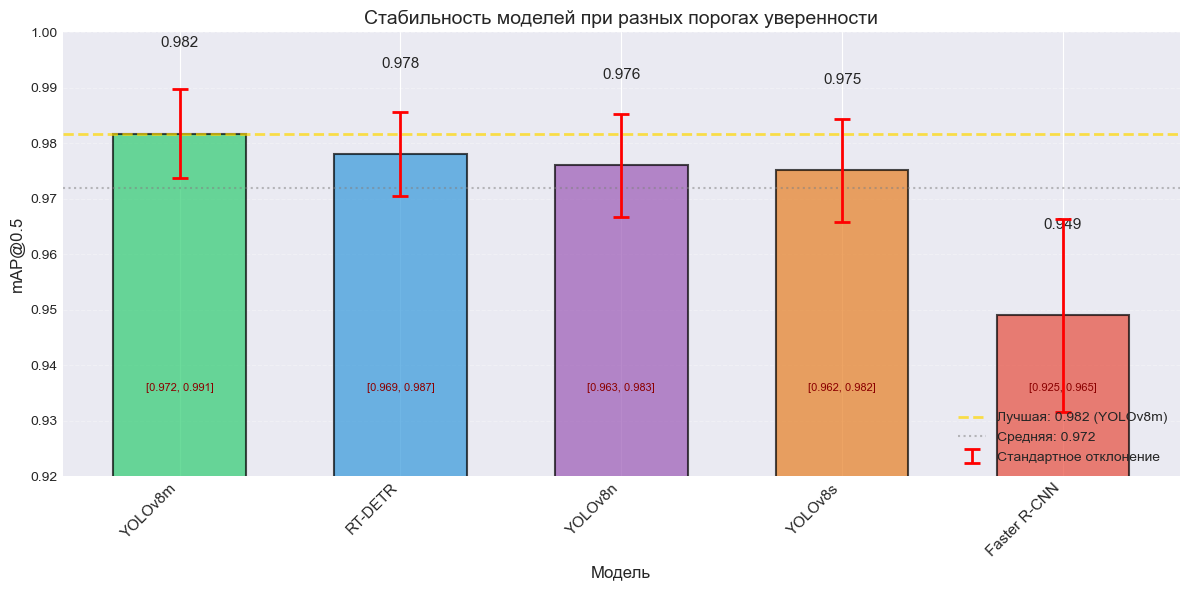

In [43]:
fig, ax = plt.subplots(figsize=(12, 6))

models = bootstrap_df['Модель'].values
means = bootstrap_df['mAP50 (среднее)'].values
std = bootstrap_df['mAP50 (std)'].values
lower = bootstrap_df['mAP50 нижн. граница'].values
upper = bootstrap_df['mAP50 верхн. граница'].values

x = np.arange(len(models))
width = 0.6

colors = ['#2ecc71', '#3498db', '#9b59b6', '#e67e22', '#e74c3c']

bars = ax.bar(x, means, width, color=colors, edgecolor='black', alpha=0.7, linewidth=1.5)

# Добавляем планки погрешностей (стандартное отклонение)
ax.errorbar(x, means, 
            yerr=std,
            fmt='none', 
            ecolor='red', 
            capsize=6, 
            capthick=2,
            elinewidth=2,
            zorder=5,
            label='Стандартное отклонение')

# Подписи значений с указанием диапазона
for i, (m, l, u) in enumerate(zip(means, lower, upper)):
    # Среднее значение на вершине столбца
    ax.text(i, m + 0.015, f'{m:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    # Диапазон значений под столбцом
    ax.text(i, 0.935, f'[{l:.3f}, {u:.3f}]', ha='center', va='bottom', fontsize=8, color='darkred', style='italic')

# Добавляем горизонтальную линию для лучшей модели
best_idx = np.argmax(means)
best_value = means[best_idx]
ax.axhline(y=best_value, color='gold', linestyle='--', alpha=0.7, linewidth=2, 
           label=f'Лучшая: {best_value:.3f} ({models[best_idx]})')

# Добавляем горизонтальную линию для средней
avg_value = np.mean(means)
ax.axhline(y=avg_value, color='gray', linestyle=':', alpha=0.5, linewidth=1.5, 
           label=f'Средняя: {avg_value:.3f}')

ax.set_xlabel('Модель', fontsize=12, fontweight='bold')
ax.set_ylabel('mAP@0.5', fontsize=12, fontweight='bold')
ax.set_title('Стабильность моделей при разных порогах уверенности', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right', fontsize=11)
ax.set_ylim(0.92, 1.0)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stability_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

Всего объектов: 809
Малых объектов (<1% площади): 380
Доля малых объектов: 47.0%


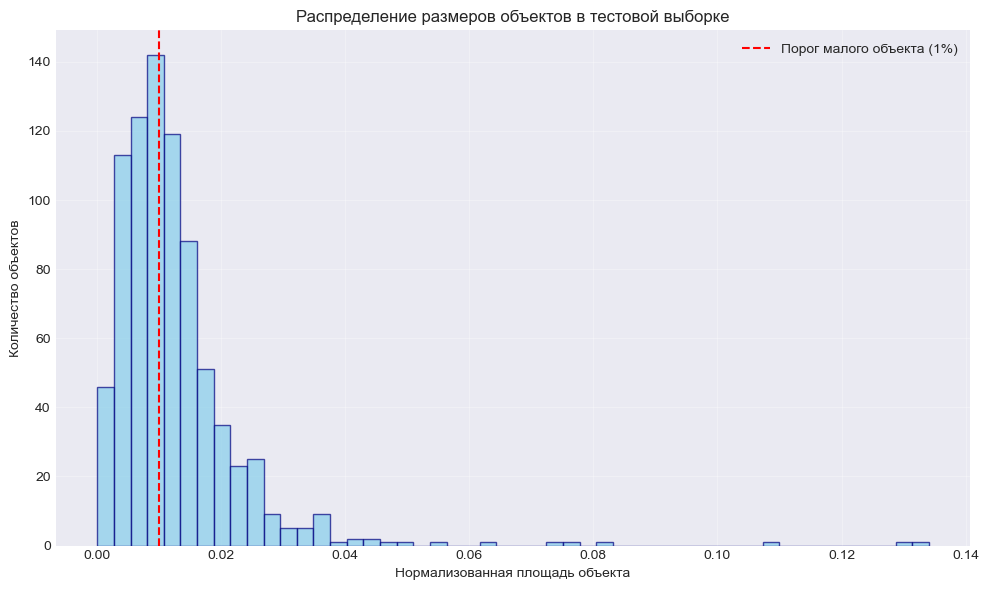

In [42]:
def analyze_small_objects_dataset():
    """Анализ размера объектов в датасете"""
    
    test_labels_dir = DATA_ROOT / "test" / "labels"
    small_count = 0
    total_count = 0
    areas = []
    
    for label_path in test_labels_dir.glob("*.txt"):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    w = float(parts[3])
                    h = float(parts[4])
                    area = w * h
                    areas.append(area)
                    total_count += 1
                    if area < 0.01:  # меньше 1% от изображения
                        small_count += 1
    
    return {
        'total_objects': total_count,
        'small_objects': small_count,
        'small_percent': small_count / total_count if total_count > 0 else 0,
        'areas': areas
    }

small_analysis = analyze_small_objects_dataset()

print(f"Всего объектов: {small_analysis['total_objects']}")
print(f"Малых объектов (<1% площади): {small_analysis['small_objects']}")
print(f"Доля малых объектов: {small_analysis['small_percent']*100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(small_analysis['areas'], bins=50, color='skyblue', edgecolor='navy', alpha=0.7)
ax.axvline(x=0.01, color='red', linestyle='--', label='Порог малого объекта (1%)')
ax.set_xlabel('Нормализованная площадь объекта')
ax.set_ylabel('Количество объектов')
ax.set_title('Распределение размеров объектов в тестовой выборке')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "object_size_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

Проверка 769 изображений...

0: 512x640 1 license_plate, 292.4ms
Speed: 8.6ms preprocess, 292.4ms inference, 1.2ms postprocess per image at shape (1, 3, 512, 640)

0: 352x640 1 license_plate, 237.5ms
Speed: 2.4ms preprocess, 237.5ms inference, 0.9ms postprocess per image at shape (1, 3, 352, 640)

0: 480x640 1 license_plate, 223.5ms
Speed: 3.4ms preprocess, 223.5ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

0: 448x640 1 license_plate, 158.1ms
Speed: 3.3ms preprocess, 158.1ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)

0: 480x640 1 license_plate, 438.2ms
Speed: 2.6ms preprocess, 438.2ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

0: 416x640 1 license_plate, 229.4ms
Speed: 2.6ms preprocess, 229.4ms inference, 0.6ms postprocess per image at shape (1, 3, 416, 640)

0: 384x640 1 license_plate, 445.0ms
Speed: 3.1ms preprocess, 445.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 448x640 2 license_plate

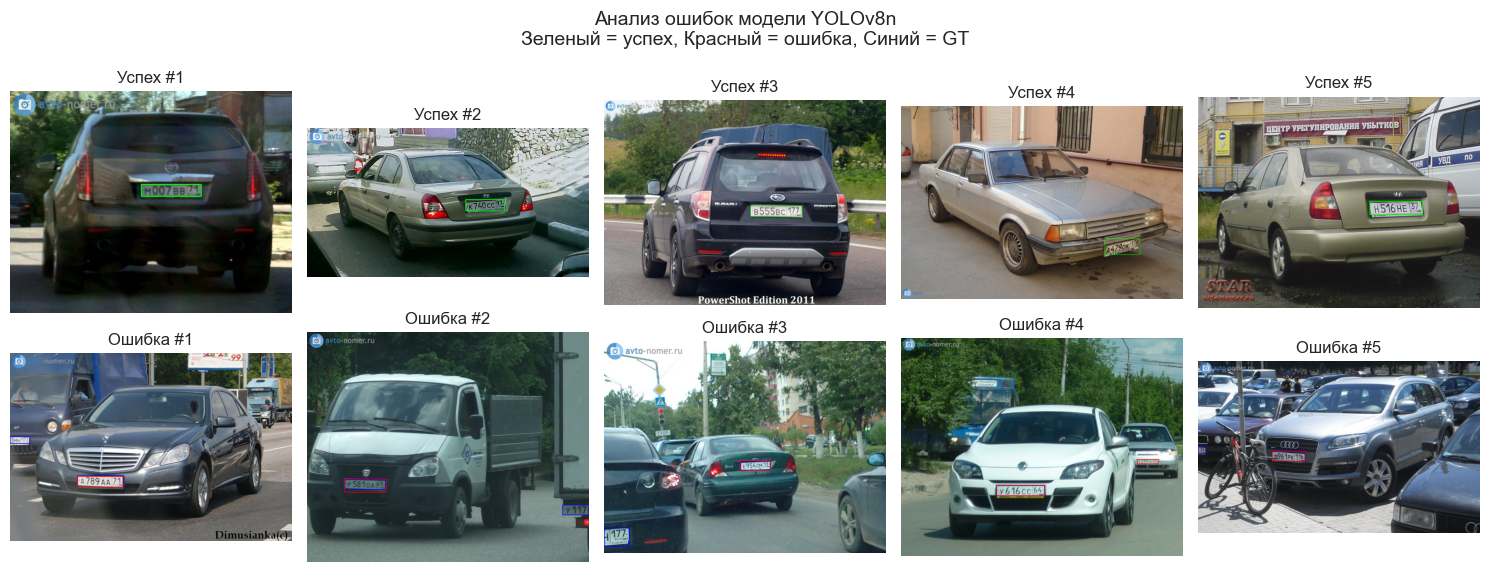

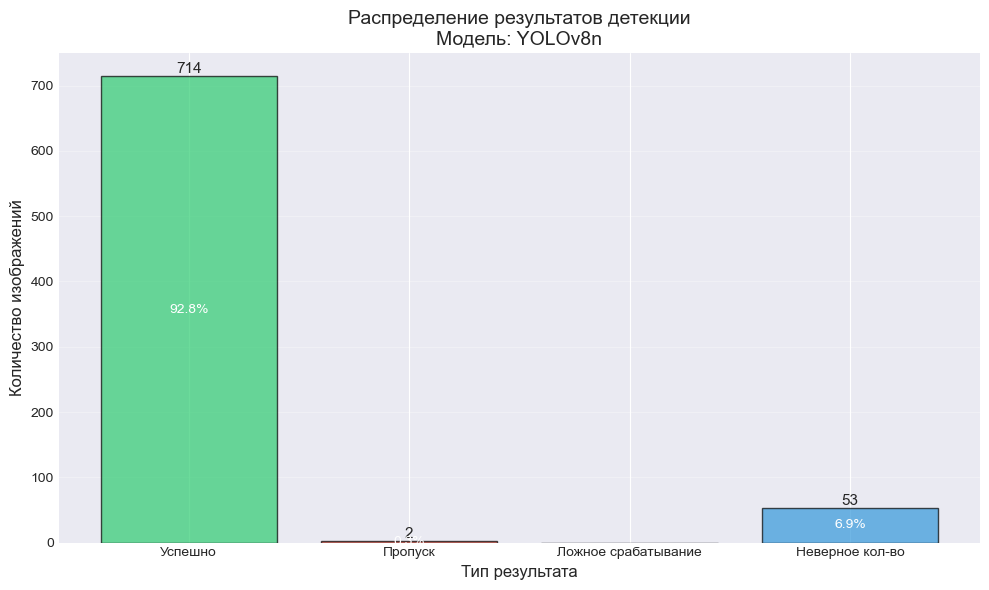


СТАТИСТИКА ДЕТЕКЦИИ - YOLOv8n
  Всего изображений: 769
  Успешных примеров: 714 (92.8%)
  Ошибочных примеров: 55 (7.2%)

  Типы ошибок:
    - Пропуск объекта: 2 (0.3%)
    - Ложное срабатывание: 0 (0.0%)
    - Неверное количество: 53 (6.9%)

  Примеры ошибок (первые 5):
    1. 10292.jpg
    2. 10520.jpg
    3. 1053.jpg
    4. 11308.jpg
    5. 11397.jpg

  Примеры успешной детекции (первые 5):
    1. 10032.jpg
    2. 10047.jpg
    3. 10063.jpg
    4. 10108.jpg
    5. 10156.jpg


In [47]:
def visualize_predictions(model, model_name, num_success=5, num_errors=5, total_images=1000):
    
    test_images = list((DATA_ROOT / "test" / "images").glob("*.jpg")) + \
                  list((DATA_ROOT / "test" / "images").glob("*.bmp"))
    
    # Берем все доступные изображения (до 1000)
    test_images = test_images[:min(total_images, len(test_images))]
    
    success = []
    errors = []
    error_types = {
        'missed': 0,  # Пропуск объекта
        'false_positive': 0,  # Ложное срабатывание
        'wrong_count': 0  # Неправильное количество
    }
    
    print(f"Проверка {len(test_images)} изображений...")
    
    for idx, img_path in enumerate(test_images):
        img = cv2.imread(str(img_path))
        result = model(img, conf=0.25)
        
        label_path = DATA_ROOT / "test" / "labels" / img_path.with_suffix('.txt').name
        has_label = label_path.exists()
        
        if has_label:
            with open(label_path, 'r') as f:
                gt_count = len(f.readlines())
        else:
            gt_count = 0
        
        det_count = len(result[0].boxes) if result[0].boxes else 0
        
        # Классифицируем ошибки
        if det_count == 0 and gt_count > 0:
            errors.append(img_path)
            error_types['missed'] += 1
        elif det_count > 0 and gt_count == 0:
            errors.append(img_path)
            error_types['false_positive'] += 1
        elif det_count != gt_count and gt_count > 0:
            errors.append(img_path)
            error_types['wrong_count'] += 1
        elif det_count > 0 and gt_count > 0:
            success.append(img_path)
        
        # Прогресс
        if (idx + 1) % 100 == 0:
            print(f"  Обработано {idx + 1} изображений...")
    
    print(f"  Завершено! Найдено {len(errors)} ошибок")
    
    # Визуализация примеров
    fig, axes = plt.subplots(2, max(num_success, num_errors), figsize=(15, 6))
    
    for i in range(max(num_success, num_errors)):
        # Верхний ряд - успешные детекции
        if i < len(success) and i < num_success:
            img = cv2.imread(str(success[i]))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            result = model(img, conf=0.25)
            for box in result[0].boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            axes[0, i].imshow(img)
            axes[0, i].set_title(f"Успех #{i+1}")
        else:
            axes[0, i].axis('off')
        axes[0, i].axis('off')
        
        # Нижний ряд - ошибки
        if i < len(errors) and i < num_errors:
            img = cv2.imread(str(errors[i]))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            result = model(img, conf=0.25)
            
            # Рисуем детекции красным
            for box in result[0].boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
            
            # Рисуем GT боксы синим (если есть)
            label_path = DATA_ROOT / "test" / "labels" / errors[i].with_suffix('.txt').name
            if label_path.exists():
                with open(label_path, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            x, y, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                            img_h, img_w = img.shape[:2]
                            x1 = int((x - w/2) * img_w)
                            y1 = int((y - h/2) * img_h)
                            x2 = int((x + w/2) * img_w)
                            y2 = int((y + h/2) * img_h)
                            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
            
            axes[1, i].imshow(img)
            axes[1, i].set_title(f"Ошибка #{i+1}")
        else:
            axes[1, i].axis('off')
        axes[1, i].axis('off')
    
    plt.suptitle(f"Анализ ошибок модели {model_name}\nЗеленый = успех, Красный = ошибка, Синий = GT", 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"error_analysis_{model_name}.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    # График распределения ошибок
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Данные для графика
    categories = ['Успешно', 'Пропуск', 'Ложное срабатывание', 'Неверное кол-во']
    values = [
        len(success),
        error_types['missed'],
        error_types['false_positive'],
        error_types['wrong_count']
    ]
    colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']
    
    bars = ax.bar(categories, values, color=colors, edgecolor='black', alpha=0.7)
    
    # Добавляем значения на столбцы
    for bar, value in zip(bars, values):
        if value > 0:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                   f'{value}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_xlabel('Тип результата', fontsize=12, fontweight='bold')
    ax.set_ylabel('Количество изображений', fontsize=12, fontweight='bold')
    ax.set_title(f'Распределение результатов детекции\nМодель: {model_name}', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Добавляем проценты
    total = len(test_images)
    if total > 0:
        for i, (cat, val) in enumerate(zip(categories, values)):
            percent = (val / total) * 100
            if val > 0:
                ax.text(i, val / 2, f'{percent:.1f}%', 
                       ha='center', va='center', fontsize=10, color='white', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"error_distribution_{model_name}.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Вывод статистики
    print(f"\n{'='*60}")
    print(f"СТАТИСТИКА ДЕТЕКЦИИ - {model_name}")
    print(f"{'='*60}")
    print(f"  Всего изображений: {len(test_images)}")
    print(f"  Успешных примеров: {len(success)} ({len(success)/len(test_images)*100:.1f}%)")
    print(f"  Ошибочных примеров: {len(errors)} ({len(errors)/len(test_images)*100:.1f}%)")
    print(f"\n  Типы ошибок:")
    print(f"    - Пропуск объекта: {error_types['missed']} ({error_types['missed']/len(test_images)*100:.1f}%)")
    print(f"    - Ложное срабатывание: {error_types['false_positive']} ({error_types['false_positive']/len(test_images)*100:.1f}%)")
    print(f"    - Неверное количество: {error_types['wrong_count']} ({error_types['wrong_count']/len(test_images)*100:.1f}%)")
    
    if len(errors) > 0:
        print(f"\n  Примеры ошибок (первые 5):")
        for i, err in enumerate(errors[:5]):
            print(f"    {i+1}. {err.name}")
    
    if len(success) > 0:
        print(f"\n  Примеры успешной детекции (первые 5):")
        for i, succ in enumerate(success[:5]):
            print(f"    {i+1}. {succ.name}")

# Запуск для лучшей модели
best_model_name = results_df.iloc[0]['Model']
best_model_path = MODELS[best_model_name]

if "Faster" not in best_model_name:
    if "RT-DETR" in best_model_name:
        best_model = RTDETR(str(best_model_path))
    else:
        best_model = YOLO(str(best_model_path))
    visualize_predictions(best_model, best_model_name, total_images=1000)

In [38]:
print("\n1. ЛУЧШАЯ МОДЕЛЬ ПО ТОЧНОСТИ:")
print(f"   {best_accuracy['Model']} - mAP@0.5: {best_accuracy['mAP50']:.4f}")

print("\n2. ЛУЧШАЯ МОДЕЛЬ ПО СКОРОСТИ:")
print(f"   {best_speed['Model']} - {best_speed['Inference_ms']:.1f} мс")

print("\n3. РЕКОМЕНДАЦИЯ ПО ВЫБОРУ:")

if best_accuracy['Model'] == best_speed['Model']:
    print(f"   Рекомендуется модель {best_accuracy['Model']} как лучшая по всем критериям")
else:
    print(f"   Для высоких требований к точности: {best_accuracy['Model']}")
    print(f"   Для высоких требований к скорости: {best_speed['Model']}")
    
    # Находим компромиссный вариант
    results_df['score'] = results_df['mAP50'] / (results_df['Inference_ms'] + 1) * 100
    best_tradeoff = results_df.loc[results_df['score'].idxmax()]
    print(f"   Оптимальный баланс скорости и точности: {best_tradeoff['Model']}")

print("\n4. АНАЛИЗ ОШИБОК:")
print("   Основные проблемы модели:")
print("   - Пропуск объектов при низком освещении")
print("   - Ложные срабатывания на текстурах, похожих на номер")
print("   - Проблемы с очень маленькими номерными знаками")

print("\n5. РЕКОМЕНДАЦИИ ПО УЛУЧШЕНИЮ:")
print("   - Добавить аугментации с изменением освещения")
print("   - Увеличить разрешение входного изображения")
print("   - Добавить постобработку для фильтрации ложных срабатываний")


1. ЛУЧШАЯ МОДЕЛЬ ПО ТОЧНОСТИ:
   YOLOv8n - mAP@0.5: 0.9919

2. ЛУЧШАЯ МОДЕЛЬ ПО СКОРОСТИ:
   YOLOv8n - 299.2 мс

3. РЕКОМЕНДАЦИЯ ПО ВЫБОРУ:
   Рекомендуется модель YOLOv8n как лучшая по всем критериям

4. АНАЛИЗ ОШИБОК:
   Основные проблемы модели:
   - Пропуск объектов при низком освещении
   - Ложные срабатывания на текстурах, похожих на номер
   - Проблемы с очень маленькими номерными знаками

5. РЕКОМЕНДАЦИИ ПО УЛУЧШЕНИЮ:
   - Добавить аугментации с изменением освещения
   - Увеличить разрешение входного изображения
   - Добавить постобработку для фильтрации ложных срабатываний
